In [3]:
# Import required libraries

import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import pylab as pl

# Statsmodels for Logistic Regression
import statsmodels.api as sm


# Sklearn for Machine Learning Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Model evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
# Read job placement dataset

df = pd.read_csv("Job_Placement_Data.csv")


# Display first 5 rows

df.head()

,gender,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_subject,degree_percentage,undergrad_degree,work_experience,emp_test_percentage,specialisation,mba_percent,status
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


In [6]:
# Number of rows and columns

df.shape

(215, 13)

In [7]:
# Display all column names

df.columns

Index(['gender', 'ssc_percentage', 'ssc_board', 'hsc_percentage', 'hsc_board',
       'hsc_subject', 'degree_percentage', 'undergrad_degree',
       'work_experience', 'emp_test_percentage', 'specialisation',
       'mba_percent', 'status'],
      dtype='object')

In [8]:
# Check datatype and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               215 non-null    object 
 1   ssc_percentage       215 non-null    float64
 2   ssc_board            215 non-null    object 
 3   hsc_percentage       215 non-null    float64
 4   hsc_board            215 non-null    object 
 5   hsc_subject          215 non-null    object 
 6   degree_percentage    215 non-null    float64
 7   undergrad_degree     215 non-null    object 
 8   work_experience      215 non-null    object 
 9   emp_test_percentage  215 non-null    float64
 10  specialisation       215 non-null    object 
 11  mba_percent          215 non-null    float64
 12  status               215 non-null    object 
dtypes: float64(5), object(8)
memory usage: 22.0+ KB


In [9]:
# Statistical summary of numerical columns

df.describe()

,ssc_percentage,hsc_percentage,degree_percentage,emp_test_percentage,mba_percent
count,215.000000,215.000000,215.000000,215.000000,215.000000
mean,67.303395,66.333163,66.370186,72.100558,62.278186
std,10.827205,10.897509,7.358743,13.275956,5.833385
min,40.890000,37.000000,50.000000,50.000000,51.210000
25%,60.600000,60.900000,61.000000,60.000000,57.945000
50%,67.000000,65.000000,66.000000,71.000000,62.000000
75%,75.700000,73.000000,72.000000,83.500000,66.255000
max,89.400000,97.700000,91.000000,98.000000,77.890000


In [10]:
# Find missing values

df.isnull().sum()

gender                 0
ssc_percentage         0
ssc_board              0
hsc_percentage         0
hsc_board              0
hsc_subject            0
degree_percentage      0
undergrad_degree       0
work_experience        0
emp_test_percentage    0
specialisation         0
mba_percent            0
status                 0
dtype: int64

In [11]:
# Count placed and not placed students

df['status'].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

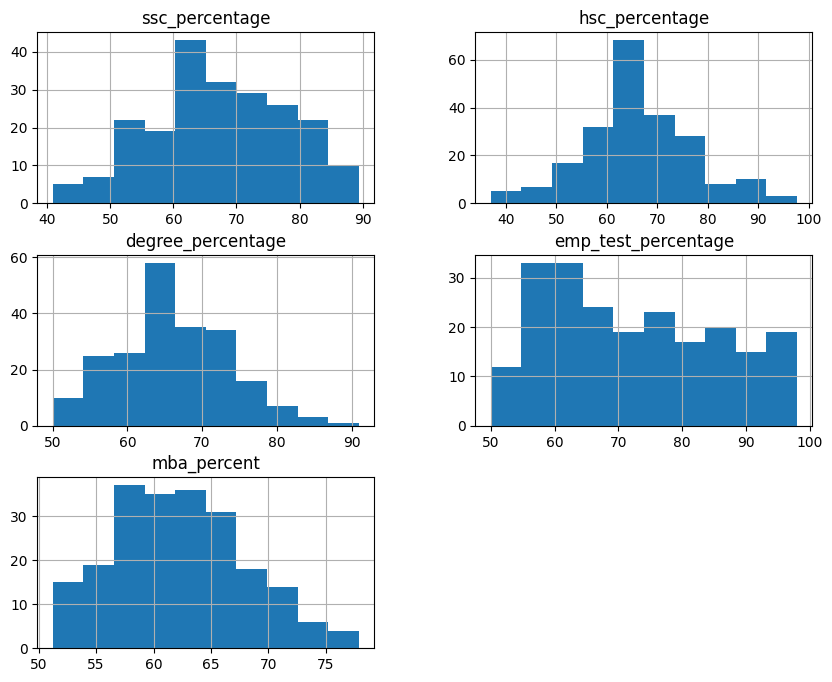

In [12]:
# Plot numerical columns

df.hist(figsize=(10,8))

pl.show()

In [13]:
# Convert status into binary values

df['status'] = df['status'].map(
    {
        'Placed':1,
        'Not Placed':0
    }
)


# Check result

df.head()

,gender,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_subject,degree_percentage,undergrad_degree,work_experience,emp_test_percentage,specialisation,mba_percent,status
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,1
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,1
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,1
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,1


In [14]:
# Convert categorical variables into dummy variables

data = pd.get_dummies(
    df,
    drop_first=True
)


# Display new dataframe

data.head()

,ssc_percentage,hsc_percentage,degree_percentage,emp_test_percentage,mba_percent,status,gender_M,ssc_board_Others,hsc_board_Others,hsc_subject_Commerce,hsc_subject_Science,undergrad_degree_Others,undergrad_degree_Sci&Tech,work_experience_Yes,specialisation_Mkt&HR
0,67.00,91.00,58.00,55.0,58.80,1,True,True,True,True,False,False,True,False,True
1,79.33,78.33,77.48,86.5,66.28,1,True,False,True,False,True,False,True,True,False
2,65.00,68.00,64.00,75.0,57.80,1,True,False,False,False,False,False,False,False,False
3,56.00,52.00,52.00,66.0,59.43,0,True,False,False,False,True,False,True,False,True
4,85.80,73.60,73.30,96.8,55.50,1,True,False,False,True,False,False,False,False,False


In [15]:
# y is target variable

y = data['status']


# X contains predictor variables

X = data.drop(
    'status',
    axis=1
)


print(X.head())

   ssc_percentage  hsc_percentage  degree_percentage  emp_test_percentage  \
0           67.00           91.00              58.00                 55.0   
1           79.33           78.33              77.48                 86.5   
2           65.00           68.00              64.00                 75.0   
3           56.00           52.00              52.00                 66.0   
4           85.80           73.60              73.30                 96.8   

   mba_percent  gender_M  ssc_board_Others  hsc_board_Others  \
0        58.80      True              True              True   
1        66.28      True             False              True   
2        57.80      True             False             False   
3        59.43      True             False             False   
4        55.50      True             False             False   

   hsc_subject_Commerce  hsc_subject_Science  undergrad_degree_Others  \
0                  True                False                    False   
1     

In [16]:
# Add constant column

X_sm = sm.add_constant(X)


X_sm.head()

,const,ssc_percentage,hsc_percentage,degree_percentage,emp_test_percentage,mba_percent,gender_M,ssc_board_Others,hsc_board_Others,hsc_subject_Commerce,hsc_subject_Science,undergrad_degree_Others,undergrad_degree_Sci&Tech,work_experience_Yes,specialisation_Mkt&HR
0,1.0,67.00,91.00,58.00,55.0,58.80,True,True,True,True,False,False,True,False,True
1,1.0,79.33,78.33,77.48,86.5,66.28,True,False,True,False,True,False,True,True,False
2,1.0,65.00,68.00,64.00,75.0,57.80,True,False,False,False,False,False,False,False,False
3,1.0,56.00,52.00,52.00,66.0,59.43,True,False,False,False,True,False,True,False,True
4,1.0,85.80,73.60,73.30,96.8,55.50,True,False,False,True,False,False,False,False,False


In [18]:
# Convert data into numeric format
# statsmodels does not accept object/bool datatype

X_sm = X_sm.astype(float)

y = y.astype(float)



# Create logistic regression model

logit = sm.Logit(
    y,
    X_sm
)


# Fit the model

result = logit.fit()




Optimization terminated successfully.
         Current function value: 0.231806
         Iterations 8


In [19]:
# Display regression summary

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 status   No. Observations:                  215
Model:                          Logit   Df Residuals:                      200
Method:                           MLE   Df Model:                           14
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                  0.6264
Time:                        19:00:05   Log-Likelihood:                -49.838
converged:                       True   LL-Null:                       -133.39
Covariance Type:            nonrobust   LLR p-value:                 2.643e-28
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                       -18.3717      5.324     -3.451      0.001     -28.806      -7.938
ssc_percentage                0.2289      0.047      4.889      0.000       0.137       0.321
hsc_percentage                0.1072      0.038      2.838      0.005       0.033       0.181
degree_percentage             0.1858      0.056      3.343      0.001       0.077       0.295
emp_test_percentage          -0.0142      0.023     -0.625      0.532      -0.059       0.030
mba_percent                  -0.2141      0.059     -3.659      0.000      -0.329      -0.099
gender_M                      1.1943      0.686      1.741      0.082      -0.150       2.539
ssc_board_Others              0.2277      0.717      0.318      0.751      -1.177       1.633
hsc_board_Others              0.3307      0.735      0.450      0.653      -1.110       1.771
hsc_subject_Commerce         -1.4979      1.361     -1.100      0.271      -4.166       1.170
hsc_subject_Science          -0.9112      1.457     -0.625      0.532      -3.767       1.945
undergrad_degree_Others      -1.1179      1.548     -0.722      0.470      -4.152       1.916
undergrad_degree_Sci&Tech    -1.7258      0.793     -2.177      0.029      -3.279      -0.172
work_experience_Yes           2.0839      0.708      2.942      0.003       0.695       3.472
specialisation_Mkt&HR        -0.2638      0.556     -0.474      0.635      -1.354       0.826
=============================================================================================
"""

In [ ]:
# Display coefficients

result.params

const                       -18.371711
ssc_percentage                0.228908
hsc_percentage                0.107213
degree_percentage             0.185770
emp_test_percentage          -0.014157
mba_percent                  -0.214131
gender_M                      1.194329
ssc_board_Others              0.227672
hsc_board_Others              0.330741
hsc_subject_Commerce         -1.497874
hsc_subject_Science          -0.911214
undergrad_degree_Others      -1.117906
undergrad_degree_Sci&Tech    -1.725758
work_experience_Yes           2.083852
specialisation_Mkt&HR        -0.263811
dtype: float64

In [22]:
# Display p-values of all variables

result.pvalues

const                        0.000558
ssc_percentage               0.000001
hsc_percentage               0.004541
degree_percentage            0.000830
emp_test_percentage          0.532061
mba_percent                  0.000253
gender_M                     0.081673
ssc_board_Others             0.750787
hsc_board_Others             0.652757
hsc_subject_Commerce         0.271144
hsc_subject_Science          0.531747
undergrad_degree_Others      0.470133
undergrad_degree_Sci&Tech    0.029452
work_experience_Yes          0.003264
specialisation_Mkt&HR        0.635217
dtype: float64

In [23]:
# Convert coefficients into odds ratio

np.exp(result.params)

const                        1.050188e-08
ssc_percentage               1.257226e+00
hsc_percentage               1.113171e+00
degree_percentage            1.204146e+00
emp_test_percentage          9.859425e-01
mba_percent                  8.072424e-01
gender_M                     3.301341e+00
ssc_board_Others             1.255674e+00
hsc_board_Others             1.392000e+00
hsc_subject_Commerce         2.236051e-01
hsc_subject_Science          4.020357e-01
undergrad_degree_Others      3.269639e-01
undergrad_degree_Sci&Tech    1.780381e-01
work_experience_Yes          8.035359e+00
specialisation_Mkt&HR        7.681184e-01
dtype: float64

In [24]:
# Predict probability

abc = result.predict(
    X_sm.iloc[0]
)


print(abc)

None    0.916205
dtype: float64


In [25]:
# See order of input columns

X.columns

Index(['ssc_percentage', 'hsc_percentage', 'degree_percentage',
       'emp_test_percentage', 'mba_percent', 'gender_M', 'ssc_board_Others',
       'hsc_board_Others', 'hsc_subject_Commerce', 'hsc_subject_Science',
       'undergrad_degree_Others', 'undergrad_degree_Sci&Tech',
       'work_experience_Yes', 'specialisation_Mkt&HR'],
      dtype='object')

In [43]:
# Give values according to X_sm columns order

abc = result.predict(
    [
        1,     # const
        
        80,    # ssc_percentage
        85,    # hsc_percentage
        75,    # degree_percentage
        
        1,     # other numeric columns
        
        0,     # dummy column 1
        1,     # dummy column 2
        0,     # dummy column 3
        1,     # dummy column 4
        0,     # dummy column 5
        0,     # dummy column 6
        1,     # dummy column 7
        0,     # dummy column 8
        0,     # dummy column 9
        1      # dummy column 10
    ]
)

print(abc)

[1.]


In [28]:
# Placement probability

print(
    "Placement Probability:",
    abc[0]
)


# Decision

if abc[0] >= 0.5:
    print("Student will be Placed")
else:
    print("Student will not be Placed")

Placement Probability: 0.9999999999086155
Student will be Placed


In [29]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
# Create logistic regression model

model = LogisticRegression(
    max_iter=100
)


# Train model

model.fit(
    X_train,
    y_train
)

c:\Users\91831\OneDrive\Documents\test\env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
# Predict test values

y_pred = model.predict(
    X_test
)


y_pred

array([1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1.,
       0., 0., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1.])

In [32]:
# Check accuracy

accuracy_score(
    y_test,
    y_pred
)

0.8837209302325582

In [33]:
# Confusion matrix

confusion_matrix(
    y_test,
    y_pred
)

array([[ 9,  3],
       [ 2, 29]])

In [34]:
# Detailed performance report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.82      0.75      0.78        12
         1.0       0.91      0.94      0.92        31

    accuracy                           0.88        43
   macro avg       0.86      0.84      0.85        43
weighted avg       0.88      0.88      0.88        43



In [35]:
# Take first student data

sample = X.iloc[[0]]


prediction = model.predict(
    sample
)


print(prediction)

[1.]


In [39]:
if prediction[0] == 1:

    print("Student is likely to get placed")

else:

    print("Student is likely not placed")

Student is likely to get placed


In [44]:
# Get probability from statsmodels

abc = result.predict(
    X_sm.iloc[0:1]
)

print("Probability:", abc.values[0])

Probability: 0.9162046767433338
